# Singular Value Decomposition

## Introduction

In the domains of science and engineering, acquired data emanating from simulations and experiments are frequently encapsulated within vectors denoted as $\mathbf{x}_k \in \mathbb{C}^n$, where the subscript $k$ designates the label corresponding to the $k$-th distinct measurement. To elucidate, $\mathbf{x}_k$ might embody diverse representations, such as an image reshaped into a column vector, the state of a physical system at time point $k$ during its temporal evolution, or a time series $\mathbf{x}_k = x(k \Delta t)$. Consequently, the collated data is often organized into a comprehensive dataset $\mathbf{X} \in \mathbb{C}^{n \times m}$.

This dataset assumes the form:

$$
\mathbf{X} = 
\begin{bmatrix}
\mid & \mid & & \mid \\
\mathbf{x}_1 & \mathbf{x}_2 & \cdots & \mathbf{x}_m\\
\mid & \mid & & \mid \\
\end{bmatrix}
$$

In numerous instances, the dimensionality of the state, denoted by $n$, is notably extensive, frequently manifesting itself in orders of millions or billions of degrees of freedom. The individual columns within $\mathbf{X}$ are conventionally termed "snapshots," and $m$ signifies the count of these snapshots within the matrix. Often, the scenario unfolds where $n \gg m$, leading to a matrix that is vertically elongated or "tall and skinny," in contrast to instances when $n \ll m$," which result in a matrix that is relatively wider or "short and fat."

## The singular value decomposition

The singular value decomposition (SVD) is a distinctive matrix decomposition that exists for any complex-valued matrix $\mathbf{X} \in \mathbb{C}^{n \times m}$:

$$
\mathbf{X} = U \Sigma V^*,
$$

where $\mathbf{U} \in \mathbb{C}^{n \times n}$ and $\mathbf{V} \in \mathbb{C}^{m \times m}$ denote unitary matrices with orthonormal columns. The unitary condition entails $\mathbf{U} \mathbf{U}^* = \mathbf{U}^* \mathbf{U} = \mathbf{I}$ and $\mathbf{V} \mathbf{V}^* = \mathbf{V}^* \mathbf{V} = \mathbf{I}$. Both matrices $\mathbf{U}$ and $\mathbf{V}$ adhere to this unitarity condition. The matrix $\Sigma \in \mathbb{R}^{n \times m}$ comprises real, non-negative entries along the diagonal and zeros elsewhere. In this context, $\mathbf{I}$ denotes the identity matrix, while the symbol $^*$ signifies the complex conjugate transpose operation.

When $n \geq m$, the matrix $\Sigma$ features a maximum of $m$ non-zero elements on its diagonal, and can be expressed as:

$$
\Sigma = 
\begin{bmatrix}
\hat{\Sigma} \\
\bm{0}
\end{bmatrix}.
$$

Hence, a precise representation of $X$ can be achieved via the "economy" SVD:

$$
\mathbf{X} = \mathbf{U} \Sigma \mathbf{V}^* =
\begin{bmatrix}
\hat{\mathbf{U}} & \hat{\mathbf{U}}^\perp
\end{bmatrix}
\begin{bmatrix}
\hat{\Sigma} \\
\bm{0}
\end{bmatrix}
\mathbf{V}^* = 
\hat{\mathbf{U}} \hat{\Sigma} \mathbf{V}^*,
$$

where the columns of $\hat{\mathbf{U}}^\perp$ span a vector space that is orthogonal and supplementary to the space spanned by $\hat{\mathbf{U}}$. The columns of matrix $\mathbf{U}$ are termed the left singular vectors of $\mathbf{X}$, while the columns of matrix $\mathbf{V}$ represent the right singular vectors. The diagonal entries of $\hat{\Sigma} \in \mathbb{R}^{m \times m}$ are denoted as singular values, and they are arranged in descending order. The rank of matrix $\mathbf{X}$ coincides with the count of non-zero singular values.

## SVD Computation

In [1]:
import numpy as np

X = np.random.rand(10, 3)
print('X:\n{}'.format(X))

Uhat, Shat, VT = np.linalg.svd(X, full_matrices=False) # Economy SVD
print('Uhat:\n{}'.format(Uhat))
print('Shat:\n{}'.format(Shat))
print('VT:\n{}'.format(VT))

X:
[[0.82672254 0.3978993  0.12099912]
 [0.44177885 0.5629366  0.77938908]
 [0.1322632  0.52594868 0.91739957]
 [0.07521804 0.14316984 0.99152286]
 [0.22152345 0.06355506 0.56823912]
 [0.33541975 0.77982887 0.89021056]
 [0.20104294 0.7081672  0.07530099]
 [0.70570967 0.78231365 0.75852144]
 [0.70011135 0.60151548 0.06113272]
 [0.00222172 0.97320273 0.3335149 ]]
Uhat:
[[-0.23493278 -0.4341574  -0.4564356 ]
 [-0.36983808  0.08439476 -0.11744701]
 [-0.3495131   0.32027525  0.10304505]
 [-0.27254339  0.52639977 -0.15790991]
 [-0.17738874  0.2287366  -0.26466555]
 [-0.42914477  0.12345411  0.1235688 ]
 [-0.20517825 -0.29309952  0.35403917]
 [-0.45181471 -0.1234281  -0.17941732]
 [-0.24883969 -0.48647575 -0.17287219]
 [-0.29630936 -0.13910459  0.68526105]]
Shat:
[2.83563455 1.19356787 0.83169264]
VT:
[[-0.40292626 -0.63734083 -0.65684632]
 [-0.53162898 -0.42120879  0.73481547]
 [-0.74499735  0.64527499 -0.16911278]]


## Matrix Approximation

As importan attribute of the Singular Value Decomposition (SVD) is its capacity to offer an optimal approximation of reduced rank to a matrix $\mathbf{X}$. With the stratification of low-rank approximations intrinsic to the SVD framework, a rank-$r$ approximation is realized through the retention of the foremost $r$ singular values and their corresponding vectors, while discarding the remaining components. The matrix $\mathbf{X} = \mathbf{U} \Sigma \mathbf{V}^*$ can be equivalently expressed as a summation of rank-one matrices:

$$
\mathbf{X} = \sum_{k=1}^m \sigma_k \mathbf{u}_k \mathbf{v}_k^* = \sigma_1 \mathbf{u}_1 \mathbf{v}_1^* + \sigma_2 \mathbf{u}_2 \mathbf{v}_2^* + \cdots + \sigma_m \mathbf{u}_m \mathbf{v}_m^*,
$$

where $\sigma_k$ corresponds to the $k$-th diagonal element of $\Sigma$, and $\mathbf{u}_k$ and $\mathbf{v}_k$ signify the $k$-th columns of matrices $\mathbf{U}$ and $\mathbf{V}$ respectively. These singular values $\sigma_k$ exhibit a decreasing sequence: $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_m \geq 0$. As such, each subsequent rank-one matrix $\sigma_k \mathbf{u}_k \mathbf{v}_k^*$ becomes progressively less influential in encapsulating the information embodied within matrix $\mathbf{X}$. In many system contexts, the singular values $\sigma_k$ exhibit rapid diminishment, facilitating the acquisition of a favorable approximation of $\mathbf{X}$ through truncation at a specified rank $r$:

$$
\mathbf{X} \approx \tilde{\mathbf{X}} = \sum_{k=1}^r \sigma_k \mathbf{u}_k \mathbf{v}_k^* = \sigma_1 \mathbf{u}_1 \mathbf{v}_1^* + \sigma_2 \mathbf{u}_2 \mathbf{v}_2^* + \cdots + \sigma_r \mathbf{u}_r \mathbf{v}_r^*.
$$

The resultant approximated matrix is denoted as:

$$
\tilde{\mathbf{X}} = \tilde{\mathbf{U}} \tilde{\Sigma} \tilde{\mathbf{V}}^*,
$$

where $\tilde{\mathbf{U}} \in \mathbb{R}^{n \times r}$, $\tilde{\Sigma} \in \mathbb{R}^{r \times r}$, and $\tilde{\mathbf{V}} \in \mathbb{R}^{m \times r}$.

### Example: Image Compression

A shape: (2000, 1500, 3)
X shape: (2000, 1500)


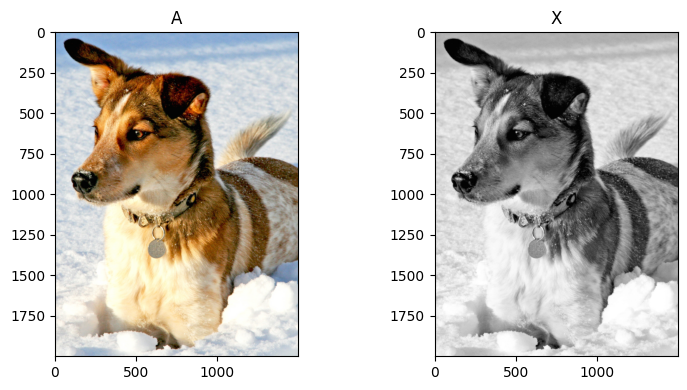

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import mltopics.utils.paths as path

img_DIR = path.data_images_dir("dog.jpg")

A = imread(img_DIR)
n, m, l = A.shape
X = np.mean(A, -1) # Convert RGB to grayscale and get the mean of the r,g,b channels
print("A shape: ({}, {}, {})".format(n, m, l))
print("X shape: ({}, {})".format(n, m))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

img0 = ax[0].imshow(A)
img1 = ax[1].imshow(X, cmap="gray")
ax[0].set_title('A')
ax[1].set_title('X')

fig.tight_layout()
plt.show()

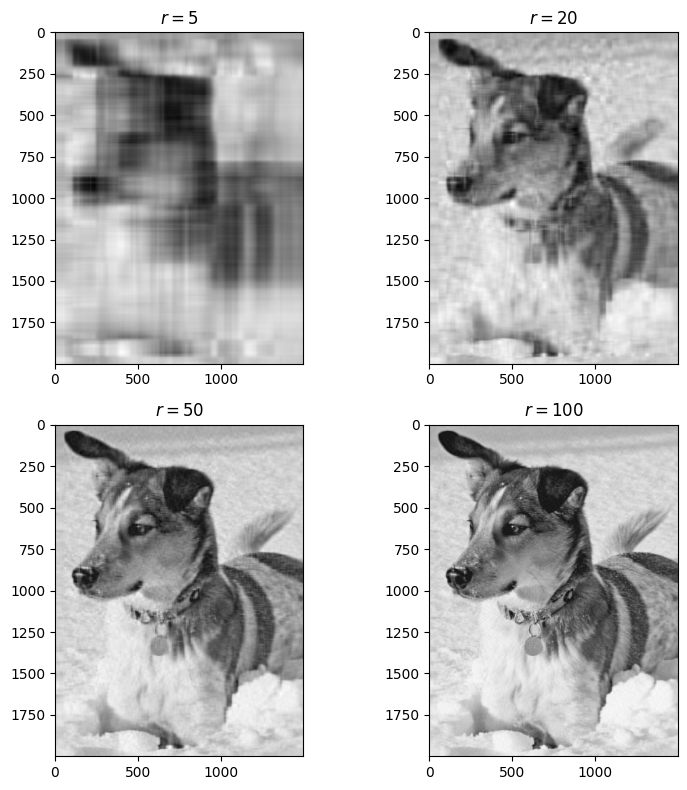

In [3]:
# Take the SVD
U, S, VT = np.linalg.svd(X, full_matrices=False)
S = np.diag(S)
ranks = [5, 20, 50, 100]

Xapprox = []
for r in ranks: # Construct approximate image
    Xapprox.append(U[:, :r] @ S[0:r, :r] @ VT[:r, :])
    
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
img0 = ax[0, 0].imshow(Xapprox[0], cmap="gray")
img1 = ax[0, 1].imshow(Xapprox[1], cmap="gray")
img2 = ax[1, 0].imshow(Xapprox[2], cmap="gray")
img3 = ax[1, 1].imshow(Xapprox[3], cmap="gray")

ax[0, 0].set_title(r"$r = ${}".format(ranks[0]))
ax[0, 1].set_title(r"$r = ${}".format(ranks[1]))
ax[1, 0].set_title(r"$r = ${}".format(ranks[2]))
ax[1, 1].set_title(r"$r = ${}".format(ranks[3]))

fig.tight_layout()
plt.show()

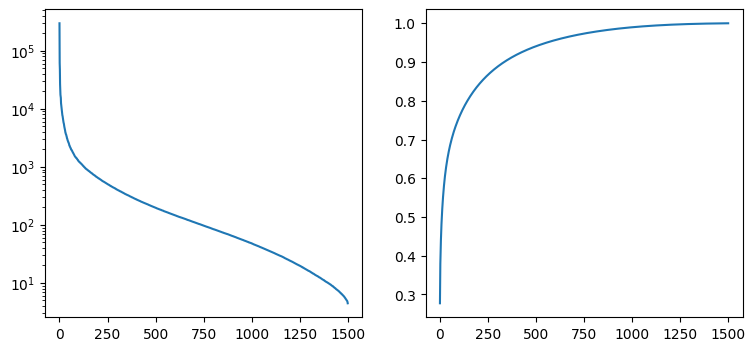

In [4]:
# Plot singular values and cumulative sum
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].semilogy(np.diag(S))
ax[1].plot(np.cumsum(np.diag(S))/np.sum(np.diag(S)))
plt.show()

In [6]:
import mltopics.utils.paths as path

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [21]:
data_DIR = path.data_raw_dir('ecg12-500hzsrfava.npy')
ecg = np.load(data_DIR)
print("ECG shape: {}".format(ecg.shape))

ECG shape: (5000, 12)


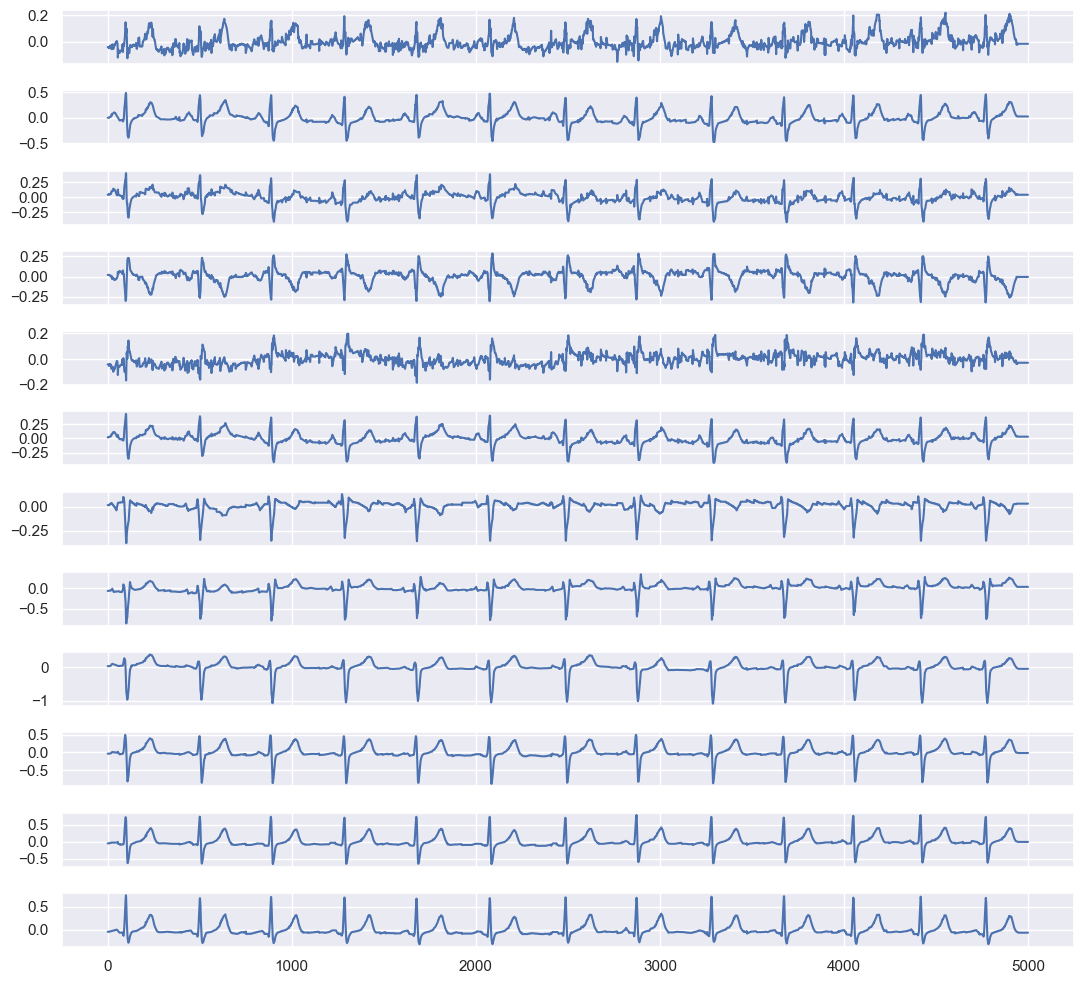

In [22]:
fig, ax = plt.subplots(ecg.shape[1], 1, figsize=(11, 10), sharex=True, sharey=False)
for i in range(ecg.shape[1]):
    ax[i].plot(ecg[:,i].ravel())
plt.tight_layout()
plt.show()

In [30]:
ecg.T.shape

(12, 5000)

In [35]:
Uhat, Shat, VThat = np.linalg.svd(ecg.T, full_matrices=False)
print('Uhat shape: {}'.format(Uhat.shape))
print('Shat shape: {}'.format(Shat.shape))
print('VThat shape: {}'.format(VThat.shape))

Uhat shape: (12, 12)
Shat shape: (12,)
VhatT shape: (12, 5000)


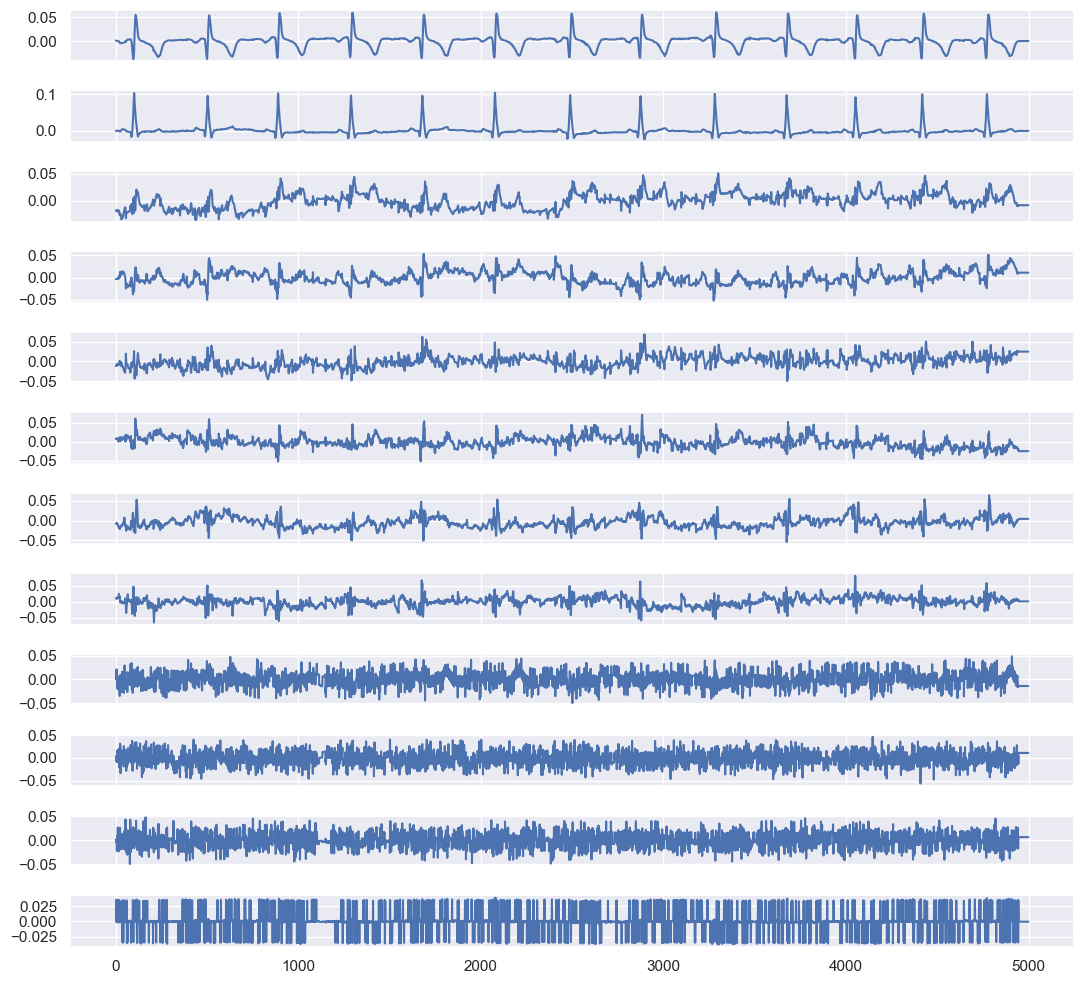

In [44]:
fig, ax = plt.subplots(12, 1, figsize=(11, 10), sharex=True, sharey=False)
for i in range(12):
    ax[i].plot(VThat[i,:].ravel())
plt.tight_layout()
plt.show()